In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy
import pandas as pd
import pickle

import onep

In [2]:
data = pd.read_csv("/Users/suthardr/Desktop/Rui_Newest_Model_July/astrocyte_shot_Gaussian_noise3.csv")

data_recall = pd.read_csv("/Users/suthardr/Desktop/Rui_Newest_Model_July/astrocyte_recall_Gaussian_noise3_origID.csv")


In [150]:
data

,Unnamed: 0,pred_a1,pred_a0,pred_mu,pred_sigma,pred_mu_sigma,variance,mean_peak,mu_1,mu_2,mu_3,mu_4,CellID,animal,orig_index
0,NaN,0.2,0.0,5.0,0.7,0.8,NaN,NaN,NaN,NaN,NaN,NaN,1,astro3,0
1,1.0,0.3,0.0,5.7,1.5,1.0,NaN,NaN,5.5,4.3,5.1,3.0,10,astro3,9
2,10.0,0.1,0.0,3.4,0.9,0.4,NaN,NaN,5.5,6.9,4.8,0.1,100,astro3,101
3,100.0,0.1,0.0,5.2,1.4,3.4,3.121298,5.725,3.1,3.2,3.6,17.7,1000,astro7,96
4,1000.0,0.0,0.0,28.8,0.8,5.4,7.616813,6.725,4.5,5.2,10.2,0.1,1001,astro7,97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,995.0,0.1,0.0,5.2,0.7,2.7,2.879091,4.125,7.5,3.8,4.6,4.4,996,astro7,92
1509,996.0,0.0,0.0,12.2,2.6,8.4,9.527985,14.425,4.8,5.0,6.7,7.6,997,astro7,93
1510,997.0,0.2,0.0,6.1,2.2,2.8,2.617091,5.425,19.7,3.2,24.5,5.3,998,astro7,94
1511,998.0,0.1,0.0,4.9,3.1,0.2,0.496655,5.100,4.0,2.5,8.1,3.7,999,astro7,95


In [3]:
# Create a list of animals to filter for
animals_to_filter_A = ['astro3', 'astro4', 'astro5', 'astro9']
animals_to_filter_B = ['astro6', 'astro7', 'astro8']

# Use .isin() to filter the DataFrame
filtered_dfA_R = data_recall[data_recall['animal'].isin(animals_to_filter_A)]
filtered_dfB_R = data_recall[data_recall['animal'].isin(animals_to_filter_B)]

filtered_dfA_FC = data[data['animal'].isin(animals_to_filter_A)]
filtered_dfB_FC = data[data['animal'].isin(animals_to_filter_B)]


/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_79113/4255770863.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(filtered_dfA_R['pred_mu'], color="#75BFAA", label="CxtA", hist_kws={'alpha':.7}, kde_kws={'linewidth':3})
/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_79113/4255770863.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.

<Figure size 640x480 with 0 Axes>

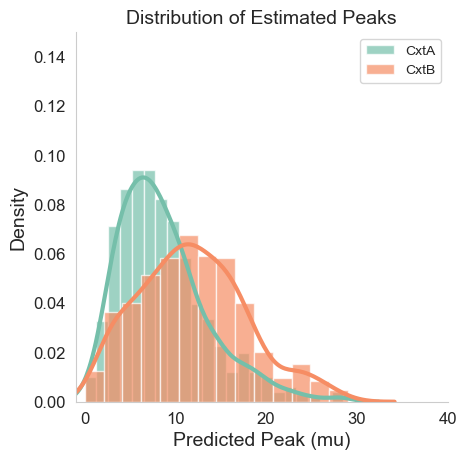

In [8]:
# Draw Plot
plt.figure()
fig, ax = plt.subplots(figsize=(4.8, 4.8))
ax.set_xlim([-1,40])
ax.set_xlabel('Time (seconds)', fontsize=14)
ax.set_ylabel('Density',fontsize=14)
ax.grid(False)
sns.despine(ax=ax)
# sns.distplot(filtered_dfB_FC['pred_mu'], color="grey", label="CxtB FC", hist_kws={'alpha':.7}, kde_kws={'linewidth':3})
sns.distplot(filtered_dfA_R['pred_mu'], color="#75BFAA", label="CxtA", hist_kws={'alpha':.7}, kde_kws={'linewidth':3})
sns.distplot(filtered_dfB_R['pred_mu'], color="#F68D64", label="CxtB", hist_kws={'alpha':.7}, kde_kws={'linewidth':3})
plt.ylim(0, 0.15)

ax.set_title('Distribution of Estimated Peaks',fontsize=14)
ax.set_xlabel('Predicted Peak (mu)',fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()
fig.savefig('/Users/suthardr/Desktop/Recall_Groups_histogram_predictedpeaks.svg')

/Users/suthardr/opt/anaconda3/envs/dCA1_Paper/lib/python3.10/site-packages/joypy/joyplot.py:435: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,


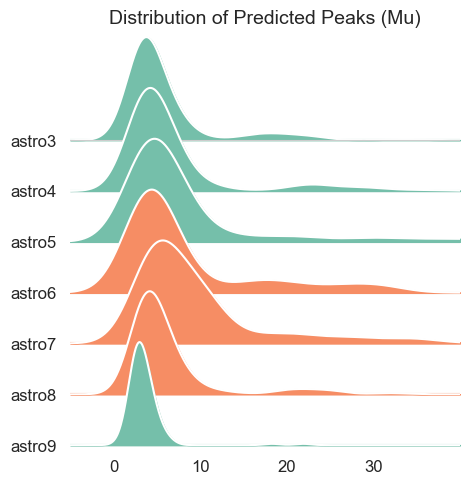

In [126]:
import matplotlib.pyplot as plt
import joypy  # Ensure you have joypy installed

colors = ["#75BFAA", "#75BFAA", "#75BFAA", "#F68D64", "#F68D64", "#F68D64", "#75BFAA"]

# Draw Plot
fig, ax = plt.subplots(figsize=(4.8, 4.8))

# Create a joyplot
joypy.joyplot(data, column=['pred_mu', 'animal'], by="animal", ylim='own', ax=ax, color=colors,
              x_range=[-5,40], linecolor='white', fade=False, xlabelsize=12, ylabelsize=12, grid='y')

plt.title('Distribution of Predicted Peaks (Mu)', fontsize=14)

# Show plot
plt.show()
#fig.savefig('/Users/suthardr/Desktop/cfc_individual mice_joyplot_histogram_predictedpeaks.svg')